# Breast Cancer Detection Project

This notebook includes:

- Data loading and understanding
- Data preprocessing and cleaning
- Missing-value handling
- Exploratory Data Analysis (EDA)
- Feature selection using statistical/model relevance
- Model building with Logistic Regression, KNN, and Random Forest
- Evaluation and model comparison
- Visualization of results
- Feature importance and final conclusion


## 1. Import Libraries


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)


## 2. Load Dataset

Loading dataset


In [17]:
import pandas as pd

df = pd.read_csv("breast_cancer_40_features_1M.csv")
df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cell_density,nucleus_size,nucleus_texture,mitosis_rate,tumor_border_irregularity,chromatin_density,cell_variation,nuclear_variation,cytoplasm_ratio,cell_clump_thickness,diagnosis
0,16.021426,15.900191,80.338711,806.403104,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,17.013208,-0.225776,0.067528,1141.097712,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,48.232473,9.387159,-0.013497,2.903146,0.574452,-1.220844,0.208864,-1.959670,-1.328186,0.196861,1
1,14.074327,14.990334,72.827789,622.307690,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,16.210277,-0.185659,-1.106335,882.935311,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,28.167857,9.823466,-0.035826,4.392747,0.189660,0.821903,0.087047,-0.299007,0.091761,-1.987569,0
2,14.893529,17.008014,89.946616,696.859332,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,0.097078,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,17.706792,-0.420645,-0.342715,849.617165,-0.161286,0.404051,1.886186,0.174578,0.257550,-0.074446,61.816547,6.934019,0.060230,1.160965,0.681766,0.301547,-0.034712,-1.168678,1.142823,0.751933,0
3,9.392390,16.336167,54.760612,277.141849,0.586857,2.190456,-0.990536,-0.566298,0.099651,-0.503476,-1.550663,0.068563,-1.062304,0.473592,-0.919424,1.549934,-0.783253,-0.322062,0.813517,-1.230864,11.922007,1.307143,-1.607483,380.483388,0.259883,0.781823,-1.236951,-1.320457,0.521942,0.296985,35.897316,11.714646,-0.680025,6.051220,0.400866,-0.714351,1.865775,0.473833,-1.191303,0.656554,0
4,18.038859,18.218585,129.752145,1022.275649,0.963376,0.412781,0.822060,1.896793,-0.245388,-0.753736,-0.889514,-0.815810,-0.077102,0.341152,0.276691,0.827183,0.013002,1.453534,-0.264657,2.720169,20.382848,-0.857158,-1.070892,1169.842728,-0.223463,0.714000,0.473238,-0.072829,-0.846794,-1.514847,2.570644,10.946676,0.214094,3.707148,0.506364,0.385317,-0.883857,0.153725,0.058209,-1.142970,1


## 3. Understand the Data


In [18]:
print('Shape of dataset:', df.shape)
display(df.head())
df.info()
display(df.describe(include='all'))


Shape of dataset: (500000, 41)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cell_density,nucleus_size,nucleus_texture,mitosis_rate,tumor_border_irregularity,chromatin_density,cell_variation,nuclear_variation,cytoplasm_ratio,cell_clump_thickness,diagnosis
0,16.021426,15.900191,80.338711,806.403104,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,17.013208,-0.225776,0.067528,1141.097712,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,48.232473,9.387159,-0.013497,2.903146,0.574452,-1.220844,0.208864,-1.959670,-1.328186,0.196861,1
1,14.074327,14.990334,72.827789,622.307690,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,16.210277,-0.185659,-1.106335,882.935311,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,28.167857,9.823466,-0.035826,4.392747,0.189660,0.821903,0.087047,-0.299007,0.091761,-1.987569,0
2,14.893529,17.008014,89.946616,696.859332,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,0.097078,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,17.706792,-0.420645,-0.342715,849.617165,-0.161286,0.404051,1.886186,0.174578,0.257550,-0.074446,61.816547,6.934019,0.060230,1.160965,0.681766,0.301547,-0.034712,-1.168678,1.142823,0.751933,0
3,9.392390,16.336167,54.760612,277.141849,0.586857,2.190456,-0.990536,-0.566298,0.099651,-0.503476,-1.550663,0.068563,-1.062304,0.473592,-0.919424,1.549934,-0.783253,-0.322062,0.813517,-1.230864,11.922007,1.307143,-1.607483,380.483388,0.259883,0.781823,-1.236951,-1.320457,0.521942,0.296985,35.897316,11.714646,-0.680025,6.051220,0.400866,-0.714351,1.865775,0.473833,-1.191303,0.656554,0
4,18.038859,18.218585,129.752145,1022.275649,0.963376,0.412781,0.822060,1.896793,-0.245388,-0.753736,-0.889514,-0.815810,-0.077102,0.341152,0.276691,0.827183,0.013002,1.453534,-0.264657,2.720169,20.382848,-0.857158,-1.070892,1169.842728,-0.223463,0.714000,0.473238,-0.072829,-0.846794,-1.514847,2.570644,10.946676,0.214094,3.707148,0.506364,0.385317,-0.883857,0.153725,0.058209,-1.142970,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   radius_mean                500000 non-null  float64
 1   texture_mean               500000 non-null  float64
 2   perimeter_mean             500000 non-null  float64
 3   area_mean                  500000 non-null  float64
 4   smoothness_mean            500000 non-null  float64
 5   compactness_mean           500000 non-null  float64
 6   concavity_mean             500000 non-null  float64
 7   concave_points_mean        500000 non-null  float64
 8   symmetry_mean              500000 non-null  float64
 9   fractal_dimension_mean     500000 non-null  float64
 10  radius_se                  500000 non-null  float64
 11  texture_se                 500000 non-null  float64
 12  perimeter_se               500000 non-null  float64
 13  area_se                    50

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cell_density,nucleus_size,nucleus_texture,mitosis_rate,tumor_border_irregularity,chromatin_density,cell_variation,nuclear_variation,cytoplasm_ratio,cell_clump_thickness,diagnosis
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.00000
mean,13.998104,19.998056,83.974858,643.922107,-0.000041,0.000145,0.000407,0.000754,0.000876,0.000718,-0.000321,0.003161,-0.002084,0.002000,-0.000401,0.001113,0.001350,0.000141,0.002216,-0.000657,16.015146,0.000931,-0.003071,837.231439,0.000569,0.000414,0.000250,-0.001373,-0.000227,-0.000799,49.984491,10.000972,-0.001488,4.034078,0.500373,-0.001654,0.000349,0.000583,0.000921,-0.001155,0.35000
std,3.003312,5.000817,19.361849,267.268212,0.998295,1.000514,0.999100,1.000124,1.000195,1.000392,1.000860,1.001423,1.000016,0.999377,1.001003,1.000066,1.000908,0.999965,0.999516,0.999762,3.154489,0.998786,0.999112,374.641550,0.999388,0.999368,1.000143,1.000022,1.001192,0.999693,14.986704,2.993361,1.001734,1.931231,0.198449,0.998966,0.999984,1.000070,0.999115,1.001496,0.47697
min,0.167713,0.023585,0.908718,0.088365,-4.871881,-4.573550,-4.573335,-4.677191,-4.482245,-4.625258,-4.980146,-4.717480,-4.829436,-4.535030,-5.305990,-4.630858,-4.317334,-4.581180,-4.480229,-4.512555,0.952646,-4.672188,-4.628390,0.129528,-4.534014,-4.393631,-4.622052,-4.823506,-4.811582,-4.380754,0.001123,0.003410,-4.809400,0.000075,0.000002,-4.638809,-4.378123,-4.631818,-5.195261,-5.118967,0.00000
25%,11.968332,16.631445,70.686941,450.004766,-0.672163,-0.674212,-0.672502,-0.674445,-0.674995,-0.674495,-0.675840,-0.673797,-0.677832,-0.670217,-0.676218,-0.673692,-0.672140,-0.674501,-0.671465,-0.675797,13.878946,-0.669923,-0.676919,565.203197,-0.676243,-0.674180,-0.674210,-0.673974,-0.674201,-0.674807,39.875003,7.983826,-0.677698,2.651846,0.363720,-0.675603,-0.672330,-0.674906,-0.673559,-0.676819,0.00000
50%,13.999959,19.995823,83.473137,615.748510,0.000494,-0.000548,0.001166,0.001707,0.001133,-0.000917,0.000016,0.001665,-0.001224,0.000973,0.000194,0.000396,0.002339,-0.000076,0.003100,0.000617,16.012841,0.002071,-0.003313,787.484309,0.000591,0.000231,0.001591,-0.000593,0.000747,-0.000063,49.976781,9.995881,-0.001108,3.997604,0.499394,-0.000409,0.001413,-0.000486,0.002245,-0.000464,0.00000
75%,16.026921,23.375633,96.715591,806.956429,0.672974,0.675908,0.677579,0.676022,0.677024,0.676145,0.674086,0.678221,0.670741,0.676619,0.673773,0.676551,0.675270,0.675315,0.675572,0.673911,18.141009,0.675476,0.669992,1054.764520,0.674838,0.673868,0.675047,0.672661,0.676207,0.673630,60.099359,12.018305,0.673039,5.350135,0.634844,0.672117,0.674692,0.674831,0.675675,0.674321,1.00000
max,28.688746,43.231374,179.969633,2585.669455,4.813692,5.220045,5.022046,4.654868,4.610534,4.574828,4.719476,4.798326,5.076480,4.731573,4.920315,4.737644,4.786108,4.678949,4.795172,4.739210,31.156600,4.984215,4.482664,4010.402944,5.128665,4.577050,5.033805,4.671005,4.358399,4.315216,122.557795,23.975959,5.019955,13.582541,1.398114,4.579820,4.434359,4.827623,4.678642,4.913122,1.00000


In [19]:
print('Column names:')
print(df.columns.tolist())


Column names:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'cell_density', 'nucleus_size', 'nucleus_texture', 'mitosis_rate', 'tumor_border_irregularity', 'chromatin_density', 'cell_variation', 'nuclear_variation', 'cytoplasm_ratio', 'cell_clump_thickness', 'diagnosis']


## 4. Data Preprocessing and Cleaning


In [20]:
# Check missing values
missing_counts = df.isnull().sum()
print('Missing values per column:')
print(missing_counts[missing_counts > 0] if (missing_counts > 0).any() else 'No missing values found.')

# Drop duplicate rows if any
before_duplicates = df.shape[0]
df = df.drop_duplicates()
after_duplicates = df.shape[0]
print(f'Duplicates removed: {before_duplicates - after_duplicates}')

# Drop irrelevant columns if present
for col in ['id', 'ID', 'Unnamed: 32']:
    if col in df.columns:
        df = df.drop(columns=col)

# Convert diagnosis column into binary format if needed
if 'diagnosis' in df.columns and df['diagnosis'].dtype == 'object':
    unique_vals = set(df['diagnosis'].dropna().unique())
    if unique_vals.issubset({'B', 'M'}):
        df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

print('\nUpdated shape:', df.shape)
display(df.head())


Missing values per column:
No missing values found.
Duplicates removed: 0

Updated shape: (500000, 41)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cell_density,nucleus_size,nucleus_texture,mitosis_rate,tumor_border_irregularity,chromatin_density,cell_variation,nuclear_variation,cytoplasm_ratio,cell_clump_thickness,diagnosis
0,16.021426,15.900191,80.338711,806.403104,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,17.013208,-0.225776,0.067528,1141.097712,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,48.232473,9.387159,-0.013497,2.903146,0.574452,-1.220844,0.208864,-1.959670,-1.328186,0.196861,1
1,14.074327,14.990334,72.827789,622.307690,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0.324084,-0.385082,-0.676922,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,16.210277,-0.185659,-1.106335,882.935311,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,28.167857,9.823466,-0.035826,4.392747,0.189660,0.821903,0.087047,-0.299007,0.091761,-1.987569,0
2,14.893529,17.008014,89.946616,696.859332,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,0.097078,0.968645,-0.702053,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,17.706792,-0.420645,-0.342715,849.617165,-0.161286,0.404051,1.886186,0.174578,0.257550,-0.074446,61.816547,6.934019,0.060230,1.160965,0.681766,0.301547,-0.034712,-1.168678,1.142823,0.751933,0
3,9.392390,16.336167,54.760612,277.141849,0.586857,2.190456,-0.990536,-0.566298,0.099651,-0.503476,-1.550663,0.068563,-1.062304,0.473592,-0.919424,1.549934,-0.783253,-0.322062,0.813517,-1.230864,11.922007,1.307143,-1.607483,380.483388,0.259883,0.781823,-1.236951,-1.320457,0.521942,0.296985,35.897316,11.714646,-0.680025,6.051220,0.400866,-0.714351,1.865775,0.473833,-1.191303,0.656554,0
4,18.038859,18.218585,129.752145,1022.275649,0.963376,0.412781,0.822060,1.896793,-0.245388,-0.753736,-0.889514,-0.815810,-0.077102,0.341152,0.276691,0.827183,0.013002,1.453534,-0.264657,2.720169,20.382848,-0.857158,-1.070892,1169.842728,-0.223463,0.714000,0.473238,-0.072829,-0.846794,-1.514847,2.570644,10.946676,0.214094,3.707148,0.506364,0.385317,-0.883857,0.153725,0.058209,-1.142970,1


In [21]:
# Separate features and target
target_col = 'diagnosis'
X_raw = df.drop(columns=[target_col])
y = df[target_col]

# Keep only numeric features
X_raw = X_raw.select_dtypes(include=[np.number])

print('Feature matrix shape after keeping numeric columns:', X_raw.shape)
print('Total missing values in feature matrix:', X_raw.isnull().sum().sum())

# Create an imputed version only for EDA/visualization
X_imputed = X_raw.copy()
X_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(X_imputed),
    columns=X_raw.columns,
    index=X_raw.index
)

Feature matrix shape after keeping numeric columns: (500000, 40)
Total missing values in feature matrix: 0


## 5. Exploratory Data Analysis (EDA)


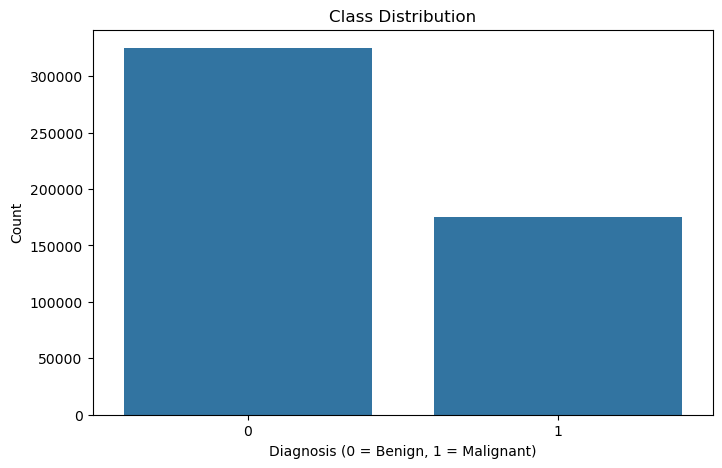

Class distribution percentage:
diagnosis
0    65.0
1    35.0
Name: proportion, dtype: float64


In [22]:
# Class distribution plot
sns.countplot(x=y)
plt.title('Class Distribution')
plt.xlabel('Diagnosis (0 = Benign, 1 = Malignant)')
plt.ylabel('Count')
plt.show()

print('Class distribution percentage:')
print((y.value_counts(normalize=True) * 100).round(2))


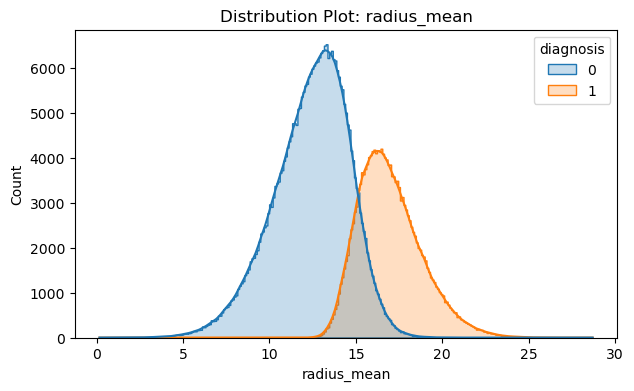

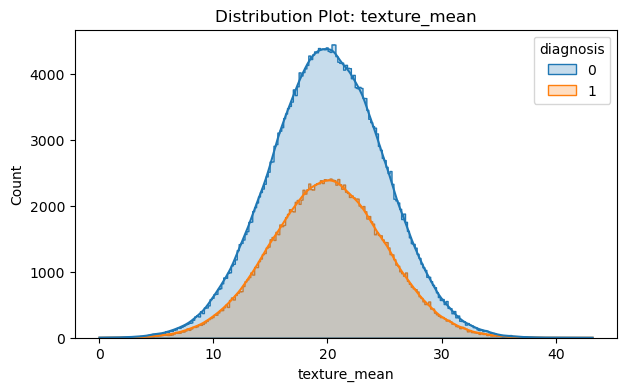

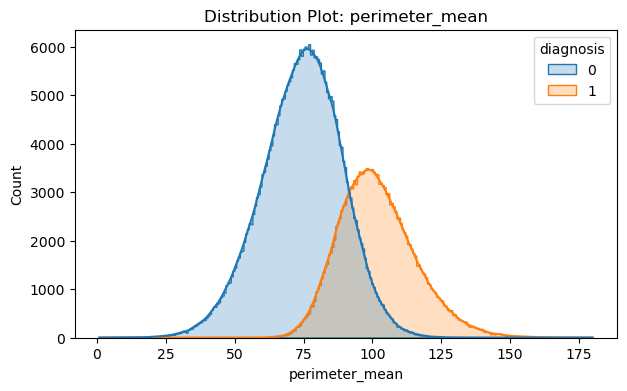

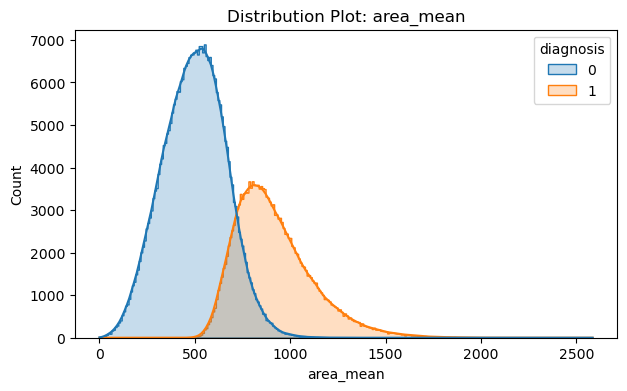

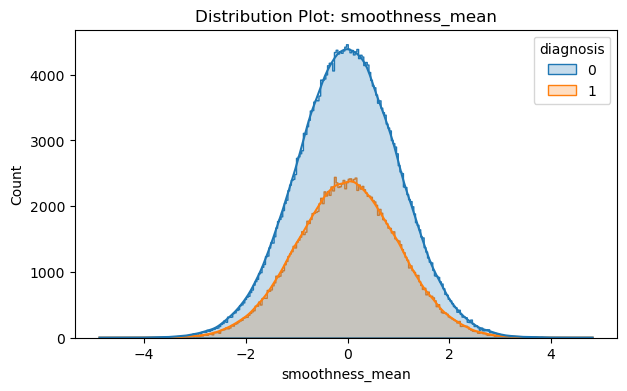

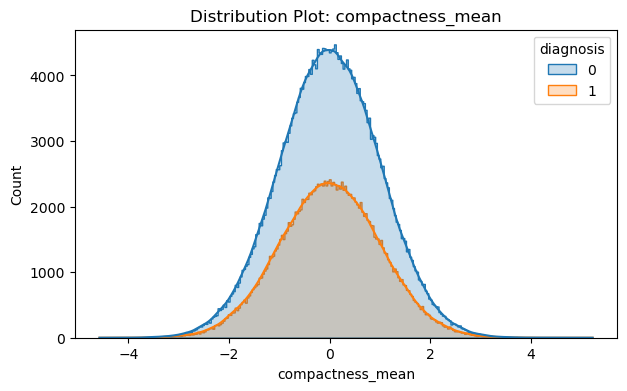

In [23]:
# Distribution plots for selected features
top_dist_features = X_imputed.columns[:6]

for col in top_dist_features:
    plt.figure(figsize=(7, 4))
    temp_df = pd.DataFrame({col: X_imputed[col], 'diagnosis': y.values})
    sns.histplot(data=temp_df, x=col, hue='diagnosis', kde=True, element='step')
    plt.title(f'Distribution Plot: {col}')
    plt.show()


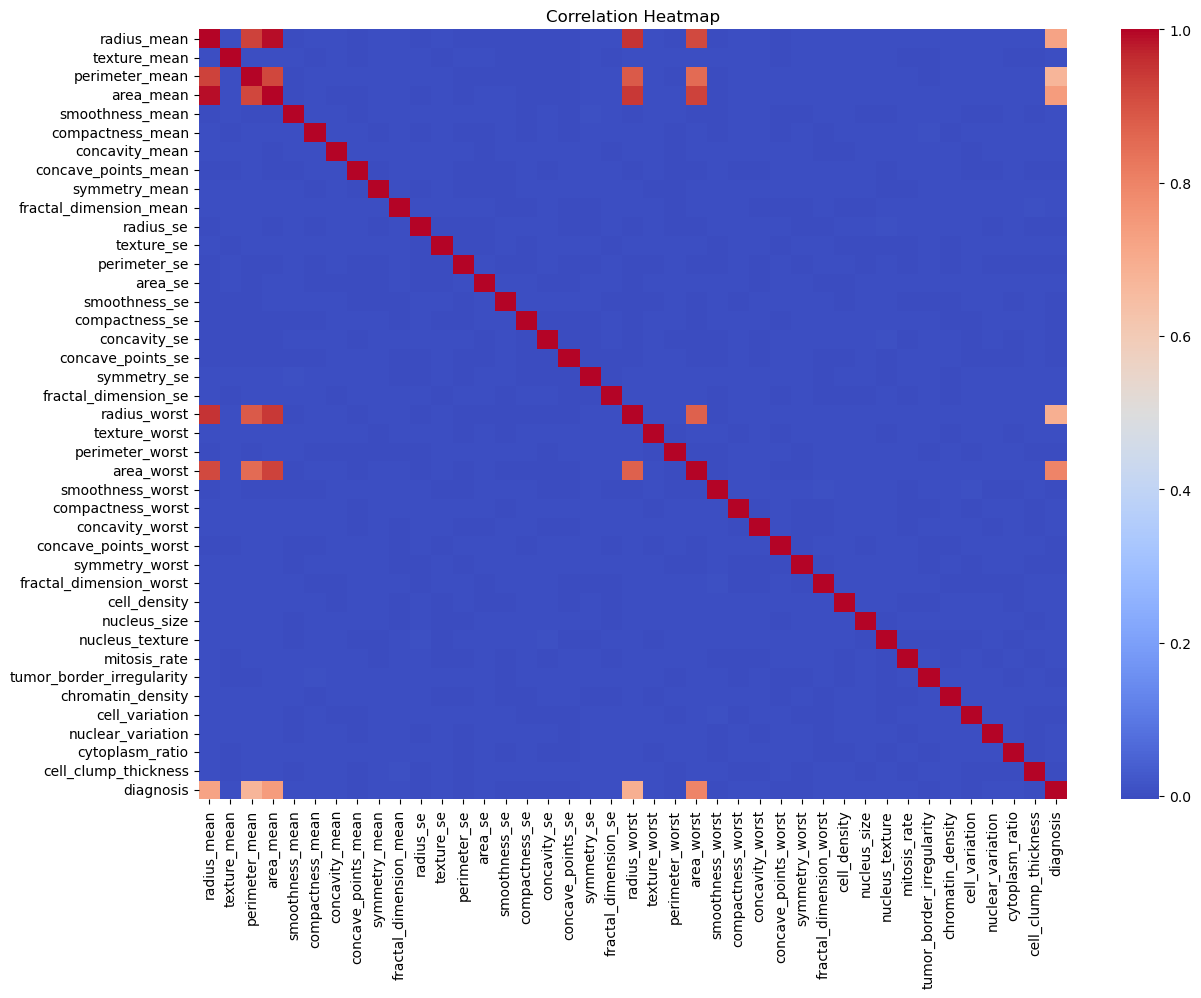

In [24]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(pd.concat([X_imputed, y], axis=1).corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


## 6. Train-Test Split


In [25]:
# 6. Train-Test Split

target_col = 'diagnosis'

X = df.drop(columns=[target_col])
y = df[target_col]

# Keep only numeric features
X = X.select_dtypes(include=[np.number])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train_raw shape: (400000, 40)
X_test_raw shape: (100000, 40)
y_train shape: (400000,)
y_test shape: (100000,)


## 7. Preprocessing on training data


In [26]:
# 7. Preprocessing on Training Data Only

# Imputer fitted only on training data
imputer = SimpleImputer(strategy='median')

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
)

print("Any missing values left in X_train?", X_train_imputed.isnull().sum().sum())
print("Any missing values left in X_test?", X_test_imputed.isnull().sum().sum())
print("X_train_imputed shape:", X_train_imputed.shape)
print("X_test_imputed shape:", X_test_imputed.shape)

Any missing values left in X_train? 0
Any missing values left in X_test? 0
X_train_imputed shape: (400000, 40)
X_test_imputed shape: (100000, 40)


## 8. Feature Selection and Engineering


In [27]:
# 8. Feature Selection and Engineering

# Select important features using training data only
k = min(15, X_train_imputed.shape[1])

selector = SelectKBest(score_func=f_classif, k=k)

X_train_selected_array = selector.fit_transform(X_train_imputed, y_train)
X_test_selected_array = selector.transform(X_test_imputed)

selected_features = X_train_imputed.columns[selector.get_support()]

X_train_selected = pd.DataFrame(
    X_train_selected_array,
    columns=selected_features,
    index=X_train_imputed.index
)

X_test_selected = pd.DataFrame(
    X_test_selected_array,
    columns=selected_features,
    index=X_test_imputed.index
)

print("Top selected features based on training data:")
print(selected_features.tolist())

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

Top selected features based on training data:
['radius_mean', 'perimeter_mean', 'area_mean', 'radius_se', 'compactness_se', 'concavity_se', 'radius_worst', 'texture_worst', 'area_worst', 'smoothness_worst', 'concavity_worst', 'fractal_dimension_worst', 'nucleus_size', 'nucleus_texture', 'chromatin_density']
X_train_selected shape: (400000, 15)
X_test_selected shape: (100000, 15)


## 9. Scaling for Logistic Regression and KNN


In [28]:
# 9. Feature Scaling (for Logistic Regression and KNN)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


X_train_scaled shape: (400000, 15)
X_test_scaled shape: (100000, 15)


## 10. Train Models

In [29]:
# 10. Train Models

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_selected, y_train)

print("All models trained successfully.")

All models trained successfully.


## 11. Evaluate Models

In [30]:
# 11. Evaluate Models

def evaluate_model(name, model, X_test_data, y_test, show_report=False, show_cm=False):
    y_pred = model.predict(X_test_data)

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }


results = []

results.append(evaluate_model('Logistic Regression', lr, X_test_scaled, y_test))
results.append(evaluate_model('KNN', knn, X_test_scaled, y_test))
results.append(evaluate_model('Random Forest', rf, X_test_selected, y_test))

results_df = pd.DataFrame(results)

print("\nModel Performance Summary:\n")
display(results_df)


Model Performance Summary:



,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.99926,0.999028,0.998857,0.998943
1,KNN,0.92728,0.904128,0.886200,0.895074
2,Random Forest,0.99917,0.998886,0.998743,0.998814


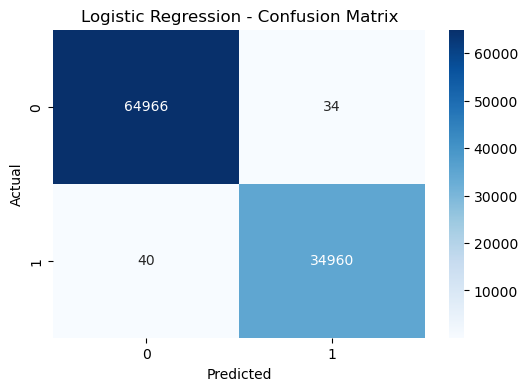

In [31]:
# Logistic Regression confusion matrix
y_pred_lr = lr.predict(X_test_scaled)
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

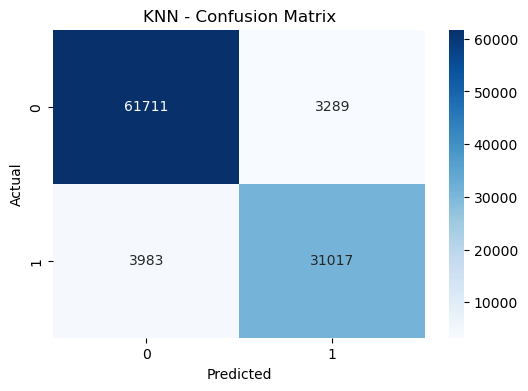

In [32]:
# KNN confusion matrix
y_pred_knn = knn.predict(X_test_scaled)
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('KNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

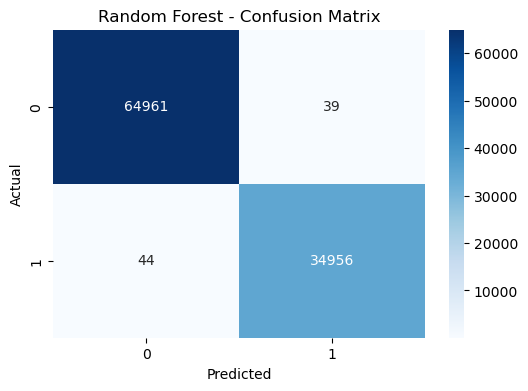

In [33]:
# Random Forest confusion matrix
y_pred_rf = rf.predict(X_test_selected)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 12. Model Comparison

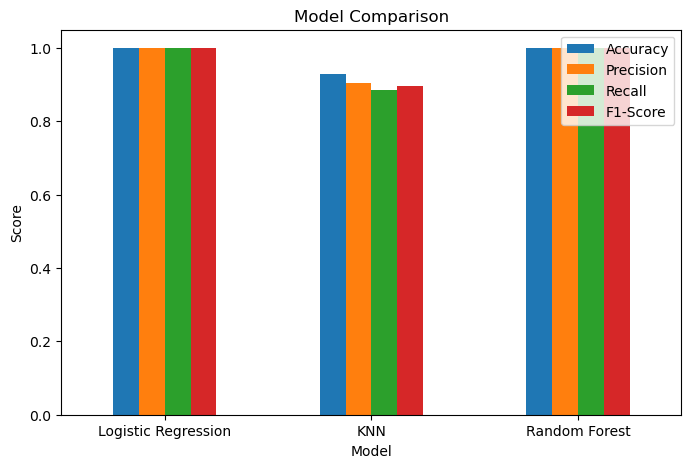

In [34]:
# 12. Model Comparison

results_df.plot(x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1-Score'], kind='bar')
plt.title('Model Comparison')
plt.xticks(rotation=0)
plt.ylabel('Score')
plt.show()

## 13. Feature Importance from Random Forest

,Feature,Importance
8,area_worst,0.556985
0,radius_mean,0.150794
2,area_mean,0.126004
6,radius_worst,0.099221
1,perimeter_mean,0.060809
10,concavity_worst,0.000756
13,nucleus_texture,0.000634
12,nucleus_size,0.000609
5,concavity_se,0.000609
7,texture_worst,0.000602


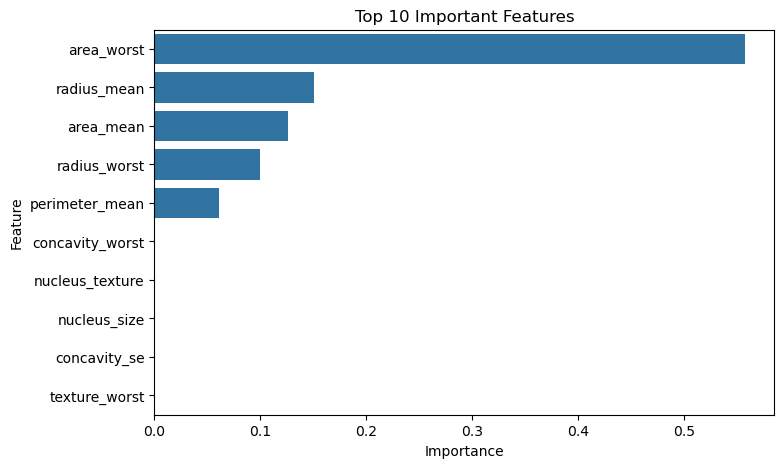

In [35]:
# 13. Feature Importance from Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features')
plt.show()

## Final Conclusion

- The project successfully applied machine learning to classify breast cancer cases as benign or malignant.
- Logistic Regression, KNN, and Random Forest were trained and compared using Accuracy, Precision, Recall, and F1-score.
- Feature selection using SelectKBest helped retain the most relevant tumor features for modeling.
- Based on the evaluation metrics, the best-performing model can support early breast cancer detection by assisting clinical decision-making.